# Sales Prediction Using Python

## Objective

The objective of this project is to build a machine learning model that predicts product sales based on advertising expenditure on TV, Radio, and Newspaper. The project includes data exploration, visualization, model training, evaluation, and interpretation of results.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_csv(r"C:\Users\Omkar\Downloads\archive\Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Step 2: Exploratory Data Analysis (EDA)

In this step, we explore the dataset by checking its shape, data types, missing values, and statistical summary.

In [7]:
print("Shape of the dataset:")
print(df.shape)

Shape of the dataset:
(200, 5)


In [8]:
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [9]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [10]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


In [11]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [12]:
print("Shape of the dataset:")
print(df.shape)
df.head()

Shape of the dataset:
(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Pairplot

The pairplot helps visualize the relationship between advertising channels and sales. It also shows the distribution of each feature.

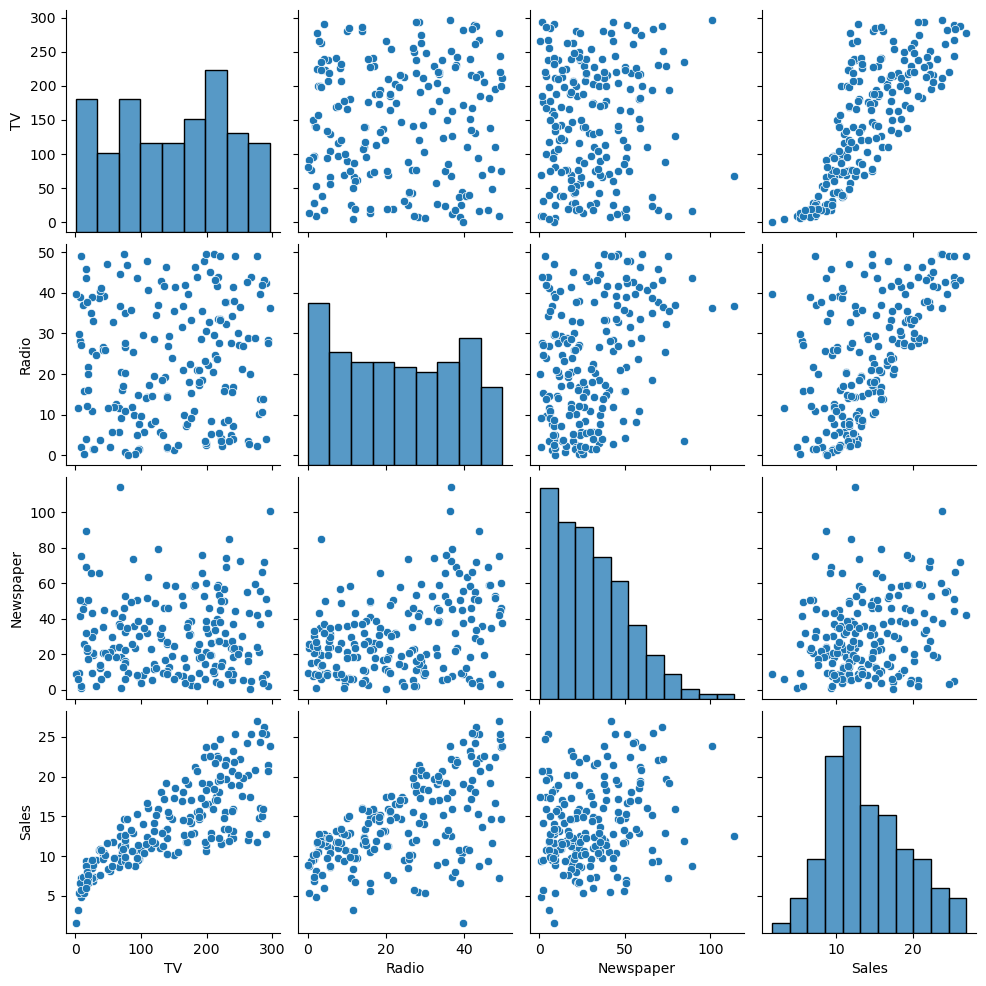

In [13]:
sns.pairplot(df)
plt.show()

### Observation

- This sales show a strong positive relationship with TV advertising.
- Radio advertising also has a positive relationship with Sales, but it is weaker than TV.
- Newspaper advertising has a relatively weak relationship with Sales.
- The features appear to have different distributions, and no major anomalies are observed.

## Scatter Plots

Scatter plots help understand how each advertising channel affects product sales.

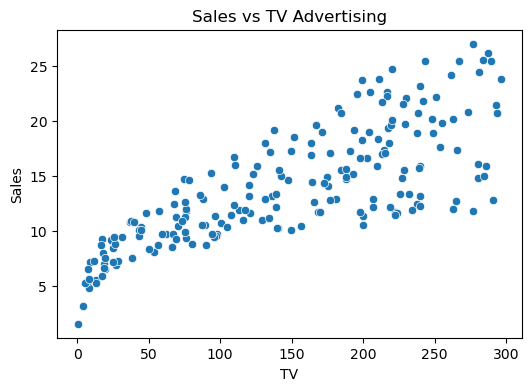

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("Sales vs TV Advertising")
plt.show()

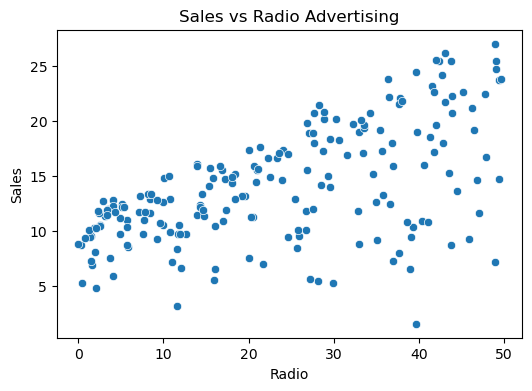

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.title("Sales vs Radio Advertising")
plt.show()

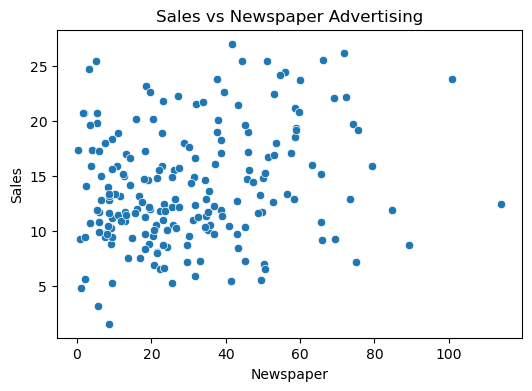

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Newspaper", y="Sales", data=df)
plt.title("Sales vs Newspaper Advertising")
plt.show()

### Observation

- TV advertising has the strongest influence on Sales, as the points show a clear upward trend.
- Radio advertising also contributes positively to Sales but with more variation.
- Newspaper advertising shows a weak relationship with Sales, indicating it has less impact compared to TV and Radio.

## Correlation Heatmap

The heatmap shows the correlation between advertising channels and sales.


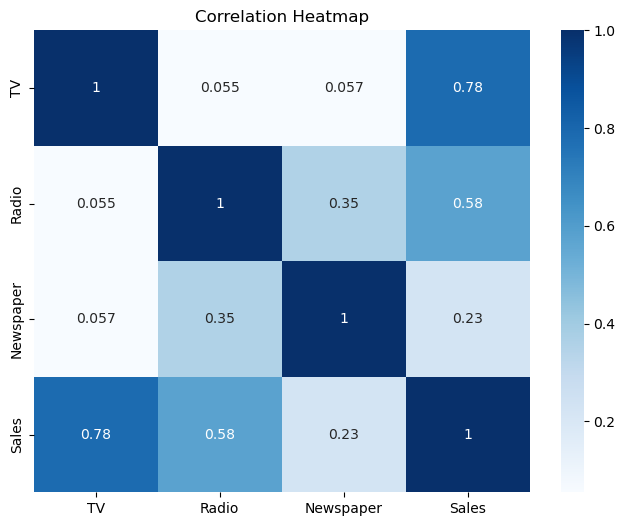

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

### Observation

- TV has the highest positive correlation with Sales.
- Radio also has a positive correlation with Sales.
- Newspaper has the weakest correlation with Sales.
- This suggests that TV advertising is the most effective channel for predicting product sales.

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [22]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 3)
Testing data shape: (40, 3)


## Linear Regression Model

Linear Regression is used as the baseline model to predict product sales based on advertising expenditure.

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Evaluation of Linear Regression Model

The model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [24]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Performance
MAE : 1.4607567168117606
RMSE: 1.7815996615334502
R² Score: 0.899438024100912


## Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [26]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Evaluation of Random Forest Regressor

The Random Forest model is evaluated using MAE, RMSE, and R² Score.

In [27]:

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
MAE : 0.6200999999999988
RMSE: 0.7685910811348248
R² Score: 0.9812843792541843


## Model Comparison

The performance of both models is compared using MAE, RMSE, and R² Score.

In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


## Best Model

### Observation

After comparing both models, the Random Forest Regressor achieved a higher R² Score (0.9813) and better prediction performance than the Linear Regression model. Therefore, Random Forest Regressor is selected as the best-performing model for this project.

## Residual Plot

A residual plot helps determine whether the prediction errors are randomly distributed. Randomly scattered residuals indicate that the model fits the data well.

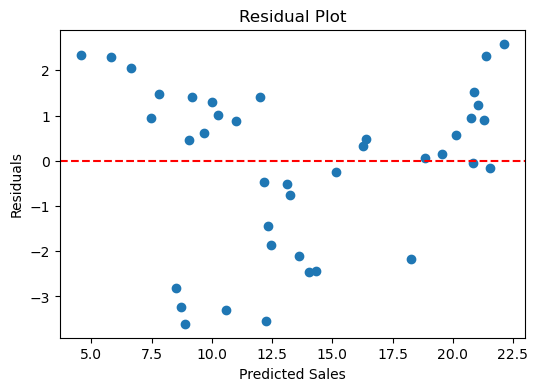

In [29]:

residuals = y_test - lr_pred

plt.figure(figsize=(6,4))
plt.scatter(lr_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Feature Importance

The coefficients of the Linear Regression model indicate how much each advertising channel contributes to predicting sales.

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

importance = importance.sort_values(by="Coefficient", ascending=False)

importance

,Feature,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


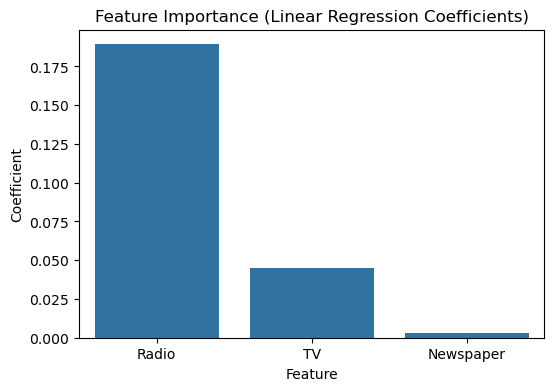

In [31]:
plt.figure(figsize=(6,4))
sns.barplot(data=importance, x="Feature", y="Coefficient")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

# Conclusion

In this project, a machine learning model was developed to predict product sales based on TV, Radio, and Newspaper advertising expenditure. Data preprocessing, exploratory data analysis, visualization, model training, and evaluation were successfully performed. Among the two models tested, Random Forest Regressor achieved the best performance with the highest R² Score. The feature importance analysis indicates that Radio advertising has the greatest impact on sales, followed by TV advertising, while Newspaper advertising has the least influence.